# Historical Modelling

**Navigation**: [← Previous: DLS Resources](03_dls_resources.ipynb) | [Next: Live Charts →](05_live_charts.ipynb)

We train logistic regression and LightGBM on historical chase balls and compare against DLS.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb


In [2]:
training = pd.read_csv(DATA_DIR / 'odi_training_sample.csv')
feature_cols = [
    'runs_scored', 'wickets_lost', 'balls_remaining', 'wickets_remaining',
    'runs_required', 'runs_required_per_ball', 'current_run_rate',
    'overs_completed', 'phase_powerplay', 'phase_death',
]
train_matches = training['match_idx'].unique()
rng = np.random.default_rng(42)
rng.shuffle(train_matches)
split = int(0.8 * len(train_matches))
train_ids, val_ids = set(train_matches[:split]), set(train_matches[split:])
train_df = training[training['match_idx'].isin(train_ids)]
val_df = training[training['match_idx'].isin(val_ids)]
X_train, y_train = train_df[feature_cols], train_df['batting_team_won']
X_val, y_val = val_df[feature_cols], val_df['batting_team_won']
print(f'Train balls: {len(X_train):,} | Val balls: {len(X_val):,}')


Train balls: 96,000 | Val balls: 24,000


## Logistic regression

In [3]:
logit = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
logit.fit(X_train, y_train)
p_logit = logit.predict_proba(X_val)[:, 1]


## LightGBM

In [4]:
lgbm = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    random_state=42, verbose=-1,
)
lgbm.fit(X_train, y_train)
p_lgbm = lgbm.predict_proba(X_val)[:, 1]


## Metrics comparison

In [5]:
p_dls = val_df['dls_prob'].values
results = []
for name, preds in [('Logistic regression', p_logit), ('LightGBM', p_lgbm), ('DLS baseline', p_dls)]:
    results.append({
        'Model': name,
        'Brier score': round(brier_score_loss(y_val, preds), 4),
        'Log loss': round(log_loss(y_val, preds), 4),
        'AUC': round(roc_auc_score(y_val, preds), 4),
    })
metrics = pd.DataFrame(results)
metrics


,Model,Brier score,Log loss,AUC
0,Logistic regression,0.2510,0.6951,0.5065
1,LightGBM,0.2573,0.7117,0.5244
2,DLS baseline,0.3584,3.7750,0.4700


## Logistic coefficients

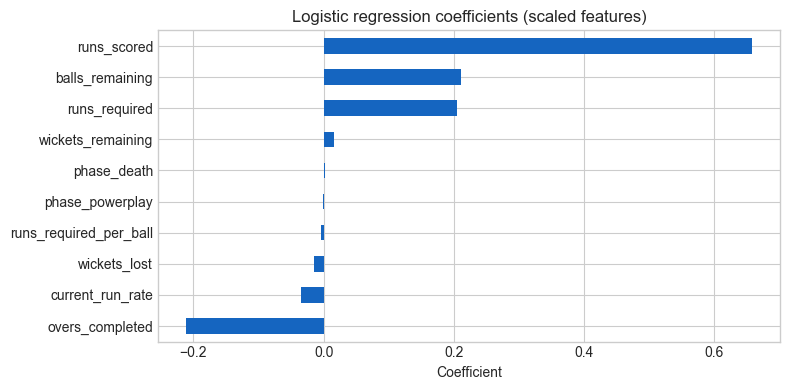

In [6]:
coefs = pd.Series(logit.named_steps['clf'].coef_[0], index=feature_cols)
fig, ax = plt.subplots(figsize=(8, 4))
coefs.sort_values().plot(kind='barh', ax=ax, color='#1565c0')
ax.set_title('Logistic regression coefficients (scaled features)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


In [7]:
import joblib
model_dir = PROJ_DIR / 'data'
joblib.dump(logit, model_dir / 'logit_model.joblib')
joblib.dump(lgbm, model_dir / 'lgbm_model.joblib')
print('Models saved.')


Models saved.


---

**Navigation**: [← Previous: DLS Resources](03_dls_resources.ipynb) | [Next: Live Charts →](05_live_charts.ipynb)
